<h1 style="color:blue">Drugi domaci iz AS,
    Aleksa Boskovic</h1>

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import io, requests, pandas as pd
from scipy.stats import bootstrap, norm
from scipy import interpolate

TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"


# orbper - orbitalni period planete
# rade - radijus planete
# eqt - rav. temp.
# st_met - metalicnost zvezde
query = """
SELECT pl_orbper, pl_rade, pl_eqt, st_met, discoverymethod 
FROM pscomppars
"""

r = requests.get(TAP_URL, params={"query": query, "format":"csv"}, timeout=120)
exo = pd.read_csv(io.StringIO(r.text))
exo.head()


,pl_orbper,pl_rade,pl_eqt,st_met,discoverymethod
0,1.003934,1.710000,1419.0,-0.05,Transit
1,8.172400,3.323214,858.0,-0.06,Transit
2,6.283855,0.800000,1108.0,0.07,Transit
3,3.173917,3.150000,1655.0,0.08,Transit
4,56.358501,4.540605,419.0,-0.20,Transit


1. Naci udeo vrucih Jupitera u prikupljenom skupu podataka (rez prikazati u procentima)

In [27]:
vj = (exo["pl_orbper"]<10) & (exo["pl_rade"] > 8) # definisano u zadatku
udeo = vj.sum()/len(vj) # nije u %
print(f"Udeo vrucih Jupitera od celog skupa: {udeo*100:.2f}%")

Udeo vrucih Jupitera od celog skupa: 11.77%


2. Pokazati da zvezde sa [Fe/H] > 0.4 imaju veci udeo vrucih jupitera u odnosu na celi uzorak.

In [28]:
metalicnost = exo["st_met"] > 0.4

# udeo vrucih jupitera sa zvezdama visoke metalicnosti
visoka_metalicnost = vj[metalicnost].sum() / metalicnost.sum()

# udeo vrucih jupitera kod zvezde niske metalinosti
niska_metalicnost = vj[~metalicnost].sum() / (~metalicnost).sum()

print(f"Udeo vrucih Jupitera u procentima kod zvezda visoke metalicnosti ([Fe/H]>0.4): {visoka_metalicnost*100:.2f}%")
print(f"Udeo vrucih Jupitera u procentima kod zvezda niske metalicnosti ([Fe/H]<0.4): {niska_metalicnost*100:.2f}%")

Udeo vrucih Jupitera u procentima kod zvezda visoke metalicnosti ([Fe/H]>0.4): 36.36%
Udeo vrucih Jupitera u procentima kod zvezda niske metalicnosti ([Fe/H]<0.4): 11.46%


3. Koristeci se istim uzorkom (visoko metalicnim zvezdama) primeniti bootstrap metodu za procenu neodredjenosti uzoracke srednje vrednosti $\bar{x}$ i uzoracke stand. devijacije $s$ za zvezdanu metalicnost. Uporediti dobijene raspodele sa analitickim izrazima:
$$\sigma_{\bar{x}} = \frac{s}{\sqrt{N}},\  \  \ \sigma_s = \frac{s}{\sqrt{2(N-1)}}$$

  Prikazati pripadajuce grafike i diskutovati: da li je pretpostavka normalnosti jednako opravdana za $\bar{x}$ i za $s$? Da li bi rezultati jackknife metode bili bolji od bootstrap metode?

N = 77
x_bar = 0.4545, s = 0.0635
Neodredjenost srednje vrednosti analiticki: 0.00724 
 bootstrap: 0.00712
Neodređenost standardne devijacije analiticki: 0.00515 
 bootstrap: 0.01215


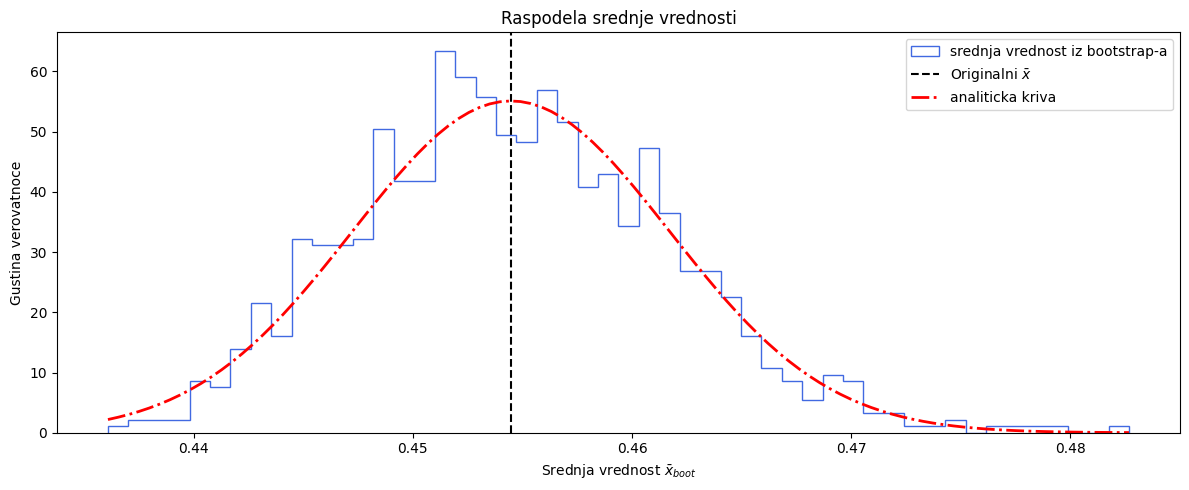

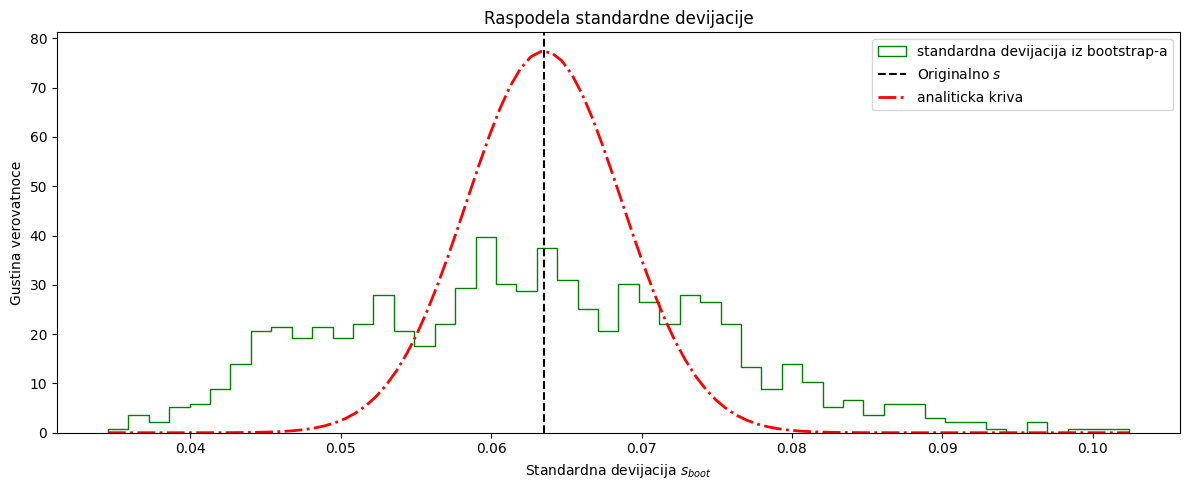

In [46]:
uzorak = exo.loc[exo["st_met"] > 0.4, "st_met"]

N = len(uzorak)
x_bar = np.mean(uzorak) # uzoracka srednja vr.
s = np.std(uzorak, ddof=1) # uzoracka stand. dev.
print(f"N = {N}")
print(f"x_bar = {x_bar:.4f}, s = {s:.4f}")

# analiticke formule iz zad
sigma_x_analiticki = s / np.sqrt(N)
sigma_s_analiticki = s / np.sqrt(2 * (N - 1))


podaci = (uzorak,)
n = 1000

rez_srv = bootstrap(podaci, np.mean, n_resamples=n, random_state=42)
rez_std = bootstrap(podaci, lambda x: np.std(x,ddof=1), n_resamples=n, random_state=42)

# neodredjenost iz bootstrapa
sigma_x_boot = rez_srv.standard_error
sigma_s_boot = rez_std.standard_error

# poredjenje analitickih i bootstrap vr.
print(f"Neodredjenost srednje vrednosti analiticki: {sigma_x_analiticki:.5f} \n bootstrap: {sigma_x_boot:.5f}")
print(f"Neodređenost standardne devijacije analiticki: {sigma_s_analiticki:.5f} \n bootstrap: {sigma_s_boot:.5f}")

# za grafik
boot_srv = rez_srv.bootstrap_distribution
boot_std = rez_std.bootstrap_distribution

# srv grafki
plt.figure(figsize=(12, 5)) 
plt.hist(boot_srv, bins=50, density=True, histtype='step', color="royalblue", lw=1, label="srednja vrednost iz bootstrap-a")
plt.axvline(x_bar, color="black", ls="--", label="Originalni $\\bar{x}$") # srednja vr. potenog uzorka

x_kriva1 = np.linspace(boot_srv.min(), boot_srv.max(), 100)
plt.plot(x_kriva1, norm.pdf(x_kriva1, loc=x_bar, scale=sigma_x_analiticki), 'r-.', lw=2, label="analiticka kriva")

plt.xlabel(r"Srednja vrednost $\bar{x}_{boot}$")
plt.ylabel("Gustina verovatnoce")
plt.title("Raspodela srednje vrednosti")
plt.legend()
plt.tight_layout()
plt.show()


# std grafik
plt.figure(figsize=(12, 5)) 
plt.hist(boot_std, bins=50, density=True, histtype='step', color="green", label="standardna devijacija iz bootstrap-a")
plt.axvline(s, color="black", ls="--", label="Originalno $s$") # std pocetnog uzorka

x_kriva2 = np.linspace(boot_std.min(), boot_std.max(), 100)
plt.plot(x_kriva2, norm.pdf(x_kriva2, loc=s, scale=sigma_s_analiticki), 'r-.', lw=2, label="analiticka kriva")

plt.xlabel(r"Standardna devijacija $s_{boot}$")
plt.ylabel("Gustina verovatnoce")
plt.title("Raspodela standardne devijacije")
plt.legend()
plt.tight_layout()
plt.show()


Na osnovu grafika mozemo jasno da zakljucimo da pretpostavka normalnosti nije jednako opravdana za $\bar{x}$ i $s$. Na prvom grafiku se vidi kako se bootstrap i analiticka kriva skoro pa savrseno poklapaju. Razlog toga je centralna granicna teorema koja garantuje da raspodela uzorackih srednjih vrednsti tezi gausovoj rapsodeli kako raste velicina uzorka. Kod standardne devijacije se vidi jasno odstupanje bootstrap od analiticke formule. Razlog ovoga je sto astronomski podaci koje imamo nikada nece biti savrseno normalni sto analiticka formula ocekuje. Sto se tice pitanja da li bi jackknife metoda bila bolja jasan odgovor je ne. Jackknice metoda je bolja za linearne statistike.

5. Naci planetu cije je $T_{eq}$ najblize $T_{eq,\oplus}$. Za nju ispisati broj zvezda u tom sistemu, broj planeta u tom sistemu, teleskop koijm je planeta otkrivena, masu planete i ekscentricnost njene orbite. 

In [49]:
TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = """
SELECT 
  pl_name,          
  pl_eqt,           
  sy_snum,          
  sy_pnum,          
  disc_telescope,   
  pl_bmasse,        
  pl_orbeccen      
FROM pscomppars
"""

r = requests.get(TAP_URL, params={"query": query, "format": "csv"}, timeout=120)
exo_new = pd.read_csv(io.StringIO(r.text))

T_eq_Zemlja = 255.0 # uzet albedo od 0.30 i solran konst od 1361 W/m^2

# trazimo planetu sa najslicnijom temp
razlika = abs(exo_new['pl_eqt'] - T_eq_Zemlja)
indeks_najblize = razlika.idxmin()

najbliza_planeta = exo_new.loc[indeks_najblize] # uzimamo podatke samo za tu planetu

print(f"Ime planete: {najbliza_planeta['pl_name']}")
print(f"Ravnotezna temp.: {najbliza_planeta['pl_eqt']} K")
print(f"Broj zvezda u sistemu: {najbliza_planeta['sy_snum']}")
print(f"Broj planeta u sistemu: {najbliza_planeta['sy_pnum']}")
print(f"Teleskop kojim je otkrivena: {najbliza_planeta['disc_telescope']}")
print(f"Masa planete: {najbliza_planeta['pl_bmasse']} m_zemlje")
print(f"Ekscentricnost orbite: {najbliza_planeta['pl_orbeccen']}")

Ime planete: HD 40307 g
Ravnotezna temp.: 255.0 K
Broj zvezda u sistemu: 1
Broj planeta u sistemu: 5
Teleskop kojim je otkrivena: 3.6 m ESO Telescope
Masa planete: 7.1 m_zemlje
Ekscentricnost orbite: 0.29


6. Koristeci ravn. temp. planeta konstruisati empirijski kumulativnu raspodelu. Primeniti metodu inverznog uzorkovanja - generisati $N_{syn} = 10^3$ uzorak iz uniformne raspodele U(0, 1) i inverznim mapirajnem preko ECDF dobiti sinteticke vrednosti $T_{eq}$. Uporediti raspodelu sintetickih uzoraka sa originalnom. Da li se ova metoda sustincki razlikuje od npr bootstrap metode? Ako da kako? Koju raspodelu bi fitovao na $T_{eq}$ i zasto?

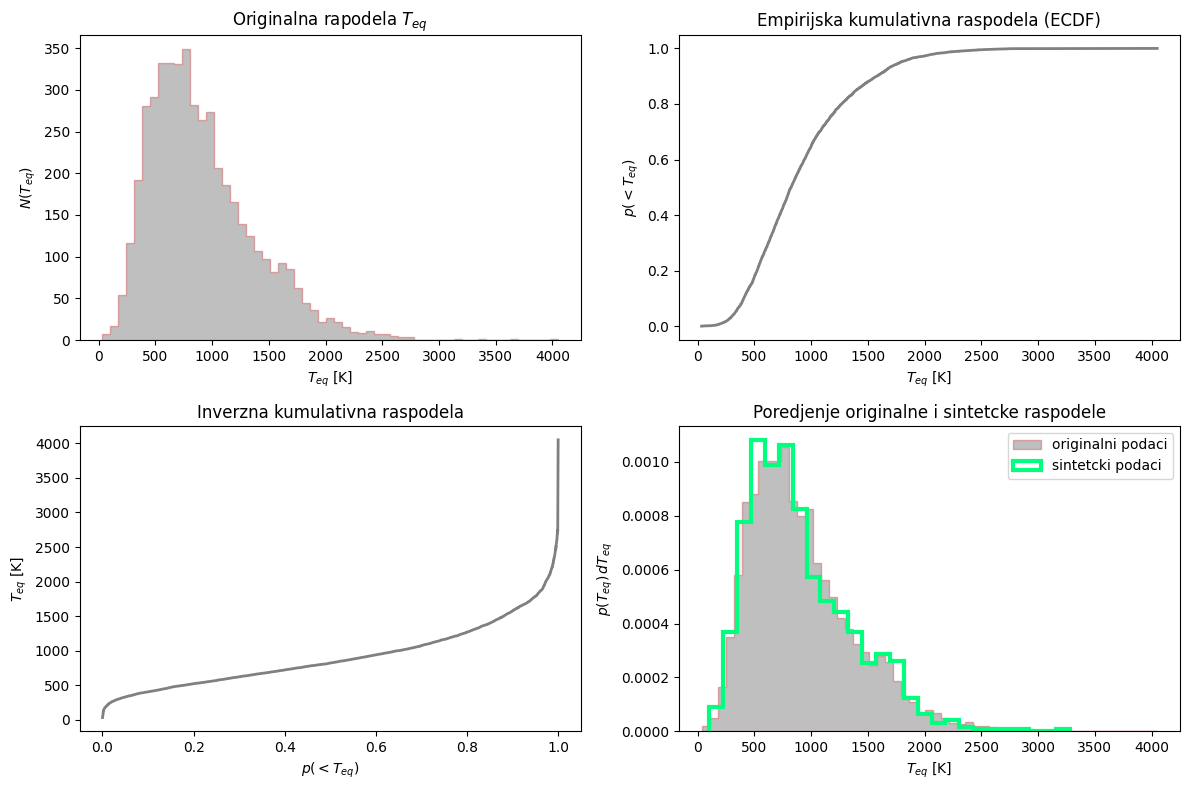

In [66]:
Teq = exo["pl_eqt"].dropna()
Teq_sort = np.sort(Teq) # sortirani mereni podaci
N_originalni = len(Teq_sort)

# empirijska kumulativna raspodela
Px_cuml = np.linspace(0, 1, N_originalni)
tck = interpolate.splrep(Px_cuml, Teq_sort) # fitovanje splajna kroz F^{-1}

# gusci grid za lepsi grafik
Px_cuml_gust = np.linspace(0, 1, 10 * N_originalni)
Teq_gust = interpolate.splev(Px_cuml_gust, tck)

# inverzno uzorkovanje
N_syn = 1000
u = np.random.uniform(0, 1, N_syn)

# mapiranje preko sintetickih uzoraka
Teq_syn = interpolate.splev(u, tck)



plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.hist(Teq_sort, bins='auto', histtype='stepfilled',
         ec='indianred', fc='grey', alpha=0.5)
plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel(r"$N(T_{eq})$")
plt.title("Originalna rapodela $T_{eq}$")


plt.subplot(222)
plt.plot(Teq_sort, Px_cuml, color='grey', lw=2)
plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel(r"$p(<T_{eq})$")
plt.title("Empirijska kumulativna raspodela (ECDF)")


plt.subplot(223)
plt.plot(Px_cuml_gust, Teq_gust, color='grey', lw=2)
plt.xlabel(r"$p(<T_{eq})$")
plt.ylabel(r"$T_{eq}$ [K]")
plt.title("Inverzna kumulativna raspodela")


plt.subplot(224)
plt.hist(Teq_sort, bins='auto', density=True, histtype='stepfilled',
         ec='indianred', fc='grey', alpha=0.5, label='originalni podaci')
plt.hist(Teq_syn, bins='auto', density=True, histtype='step',
         color='springgreen', lw=3, label='sintetcki podaci')
plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel(r"$p(T_{eq})\,dT_{eq}$")
plt.title("Poredjenje originalne i sintetcke raspodele")
plt.legend()
plt.tight_layout()
plt.show()

Da ova metoda se razlikuje od bootstrap metode. Sa grafika inverzne kumulativne raspodele vidimo da je to glatka kriva zbog splajna. Bootstrap radi suprotno on samo uzima direktno iz postojecih podataka, i zato ostajemo na istom skupu vrednosti kao originalni podaci. A inverzno uzorkovanje ima slobodu da generise nove vrednosti van pocetnog skupa.

Na prvi pogled najbolja raspodela da se prilagodi za $T_{eq}$ bi bila gama raspodela, zato sto naglo dolazimo do maksimuma i imamo veoma dug rep sa desne strane, a gama raspodela nam daje mogucnost da kontrolisemo stepen asimetrije i izgled repa